<a href="https://colab.research.google.com/github/Dreamer97JB/Abstracts_Classification_IA/blob/main/Christian_Escobar_Abstract_Classification_fix2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 1  - Preparación del Dataset

## Montar el Dataset desde GoogleDrive

Montar Repositorio de Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Cargar el Archivo desde la raíz de Google Drive

In [2]:
import pandas as pd
# Aquí cambias la ruta para que apunte a la carpeta donde tengas tu archivo
file_path = '/content/drive/MyDrive/googleScholarPeriodAbs.xlsx'

df = pd.read_excel(file_path)

df.head()  # Ver las primeras filas


,Column1,Title,Authors,Citations_counts,sumj,Year,Journal,Abstract,period,IsEnglish,SearchCriteria
0,0,Scientific writing as a social act: A review o...,C Bazerman,213,C Bazerman - New essays in technical and scien...,2019,New essays in technical and scientific …,This chapter reviews the literature in the soc...,2024-2019,True,search1period1
1,1,"Benefits, motivations, and challenges of inter...","J Dusdal, JJW Powell",177,"J Dusdal, JJW Powell - Science and Public Poli...",2021,Science and Public Policy,Contemporary science is marked by expanding an...,2024-2019,True,search1period1
2,2,Organisation matters: towards an organisationa...,S Rödder,46,S Rödder - Journal of Communication Management...,2020,Journal of Communication Management,This paper looks at science communication thro...,2024-2019,True,search1period1
3,3,Science education in the era of a pandemic: Ho...,S Erduran,159,"S Erduran - Science & Education, 2020 - Springer",2020,Science & Education,"In late February 2019, when the Covid-19 crisi...",2024-2019,True,search1period1
4,4,"On methods, ontologies, and representation in ...",JH Fujimura,160,JH Fujimura - Social organization and social p...,2024,Social organization and social process,We are weak today in ideal matters because int...,2024-2019,True,search1period1


## Limpieza de Datos

In [ ]:
# Lista de columnas que no conservaremos ya que no aportan al análisis
columns_to_drop = [
    'Column1',
    'IsEnglish',
    'SearchCriteria',
    'period',
    'sumj'
]

# Creamos un nuevo DataFrame sin esas columnas
df_clean = df.drop(columns=columns_to_drop, axis=1)

# Verificamos las columnas resultantes
print(df_clean.columns)

Index(['Title', 'Authors', 'Citations_counts', 'Year', 'Journal', 'Abstract'], dtype='object')


Verificación de Datos Nulos

In [ ]:
# Ver cuántos valores nulos hay en cada columna
df_clean.isnull().sum()

,0
Title,0
Authors,625
Citations_counts,0
Year,0
Journal,2120
Abstract,293


In [ ]:
import pandas as pd

# 1. Rellenar Journal y Authors con etiqueta genérica
df_clean = df_clean.fillna({
    'Journal': 'NoJournal',
    'Authors': 'NoAuthors'
})

# 2. Eliminar filas que no tengan Abstract (4.3% de datos)
df_clean.dropna(subset=['Abstract'], inplace=True)

# 3. Verificar cuántos nulos quedan
print("Nulos después del tratamiento:\n", df_clean.isnull().sum())

Nulos después del tratamiento:
 Title               0
Authors             0
Citations_counts    0
Year                0
Journal             0
Abstract            0
dtype: int64


Revisión de Duplicidad de Datos

In [ ]:
# Verificar si existen datos Duplicados
df_clean.duplicated().sum()

285

Relizamos un análisis para revisar los datos duplicados

In [ ]:
duplicates = df_clean[df_clean.duplicated(keep=False)]
duplicates

,Title,Authors,Citations_counts,Year,Journal,Abstract
0,Scientific writing as a social act: A review o...,C Bazerman,213,2019,New essays in technical and scientific …,This chapter reviews the literature in the soc...
4,"On methods, ontologies, and representation in ...",JH Fujimura,160,2024,Social organization and social process,We are weak today in ideal matters because int...
7,Recoding liberalism: philosophy and sociology ...,M Beddeleem,34,2020,Nine lives of neoliberalism,"In the wake of the global financial crisis, th..."
11,Science Studies and Sociology,NoAuthors,1,2022,NoJournal,"… In historians of science, however, the socio..."
12,The sociology of science and social constructi...,ME Lynch,9,2019,The Routledge handbook of social epistemology,Constructivism is a theoretical position that ...
...,...,...,...,...,...,...
6526,"Science, truth and history, part II. Metaphysi...",N Tosh,19,2007,Studies in History and Philosophy of Science P...,Historians of science have frequently sought t...
6533,"The politics of display: Museums, science, cul...",S Macdonald,788,1998,NoJournal,"The Politics of Display: Museums, science, cul..."
6631,Ways of knowing and doing STS: Niki Vermeulen ...,NoAuthors,0,2018,NoJournal,It is a special moment in the history of STS. ...
6664,"CHAPTER THREE SOCIO-TECHNICAL CONTROVERSIES, D...",P GARCÍA,0,2014,DÍAZ - Varieties of Liberalism: Contemporary …,Claims for more public and expert participatio...


Procedemos a eliminar los datos duplicados y ajustamos los tipos de datos para cada columna

In [ ]:
import pandas as pd

# 1. Crear un DataFrame sin duplicados
df_no_duplicates = df_clean.drop_duplicates()

# 2. Crear una copia explícita para evitar problemas de vistas
df_no_duplicates = df_no_duplicates.copy()

# 3. Ajustar los tipos de datos
# 3.1. Convertir 'Title' a texto (string)
df_no_duplicates.loc[:, 'Title'] = df_no_duplicates['Title'].astype(str)

# 3.2. Convertir 'Authors' a texto (string)
df_no_duplicates.loc[:, 'Authors'] = df_no_duplicates['Authors'].astype(str)

# 3.3. Convertir 'Citations_counts' a numérico (int, manejando valores no convertibles)
df_no_duplicates.loc[:, 'Citations_counts'] = pd.to_numeric(df_no_duplicates['Citations_counts'], errors='coerce').fillna(0).astype(int)

# 3.4. Convertir 'Year' a numérico (int, manejando errores de conversión)
df_no_duplicates.loc[:, 'Year'] = pd.to_numeric(df_no_duplicates['Year'], errors='coerce').fillna(0).astype(int)

# 3.5. Convertir 'Journal' a texto (string)
df_no_duplicates.loc[:, 'Journal'] = df_no_duplicates['Journal'].astype(str)

# 3.6. Convertir 'Abstract' a texto (string)
df_no_duplicates.loc[:, 'Abstract'] = df_no_duplicates['Abstract'].astype(str)

# 4. Ver cuántas filas quedaron después de eliminar duplicados
print("Filas antes:", df_clean.shape[0])
print("Filas después:", df_no_duplicates.shape[0])

# 5. Guardar en un CSV
df_no_duplicates.to_csv('data_clean_no_duplicates.csv', index=False)

# 6. Confirmar los tipos de datos después de la conversión
print(df_no_duplicates.info())

# 7. Revisar el resultado
df_no_duplicates.head()


Filas antes: 6476
Filas después: 6191
<class 'pandas.core.frame.DataFrame'>
Index: 6191 entries, 0 to 6768
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Title             6191 non-null   object
 1   Authors           6191 non-null   object
 2   Citations_counts  6191 non-null   int64 
 3   Year              6191 non-null   int64 
 4   Journal           6191 non-null   object
 5   Abstract          6191 non-null   object
dtypes: int64(2), object(4)
memory usage: 338.6+ KB
None


,Title,Authors,Citations_counts,Year,Journal,Abstract
0,Scientific writing as a social act: A review o...,C Bazerman,213,2019,New essays in technical and scientific …,This chapter reviews the literature in the soc...
1,"Benefits, motivations, and challenges of inter...","J Dusdal, JJW Powell",177,2021,Science and Public Policy,Contemporary science is marked by expanding an...
2,Organisation matters: towards an organisationa...,S Rödder,46,2020,Journal of Communication Management,This paper looks at science communication thro...
3,Science education in the era of a pandemic: Ho...,S Erduran,159,2020,Science & Education,"In late February 2019, when the Covid-19 crisi..."
4,"On methods, ontologies, and representation in ...",JH Fujimura,160,2024,Social organization and social process,We are weak today in ideal matters because int...


Dado que se ha dado la especificidad de que los textos deben ser clasificados en las categorías: ["Realista", "Constructivista", "Relativista", "Pragmatista"] deberemos hacer un proceso adicional de limpieza para preparar los datos de tal manera que mediante un modelo pre-entrenado podamos clasficar los textos haciendo uso de la coherencia semántica.


## Preprocesar el DataFrame

Se procese a limpiar espacios remover caracteres especiales, textos que sean inferiores a 20 caracters si los hubiese.

In [ ]:
#  Paso 2: Importar librerías
import pandas as pd
import re

#  Paso 3: Asegurar que la columna 'Abstract' en df_no_duplicates sea texto
df_no_duplicates['Abstract'] = df_no_duplicates['Abstract'].astype(str)

#  Paso 4: Función para limpiar los abstracts
def clean_text(text):
    text = text.lower()  # Convertir a minúsculas
    text = re.sub(r'\s+', ' ', text)  # Remover espacios extra
    text = re.sub(r'[^\w\s]', '', text)  # Remover caracteres especiales
    return text.strip()

# Aplicar limpieza a la columna 'Abstract'
df_no_duplicates['Abstract'] = df_no_duplicates['Abstract'].apply(clean_text)

#  Paso 5: Eliminar abstracts demasiado cortos (< 20 caracteres)
df_no_duplicates = df_no_duplicates[df_no_duplicates['Abstract'].str.len() > 20]

#  Paso 6: Mostrar las primeras filas para verificar el preprocesamiento
print("Primeras filas del dataset preprocesado:")
print(df_no_duplicates.head())


Primeras filas del dataset preprocesado:
                                               Title               Authors  \
0  Scientific writing as a social act: A review o...            C Bazerman   
1  Benefits, motivations, and challenges of inter...  J Dusdal, JJW Powell   
2  Organisation matters: towards an organisationa...              S Rödder   
3  Science education in the era of a pandemic: Ho...             S Erduran   
4  On methods, ontologies, and representation in ...           JH Fujimura   

   Citations_counts  Year                                   Journal  \
0               213  2019  New essays in technical and scientific …   
1               177  2021                 Science and Public Policy   
2                46  2020       Journal of Communication Management   
3               159  2020                       Science & Education   
4               160  2024    Social organization and social process   

                                            Abstract  
0  this 

## Clasificación de los artículos

Dado que no tenemos etiquetas previas para nuestros abstracts, usaremos **Zero-Shot Learning**, una técnica que permite clasificar texto sin necesidad de entrenamiento.

**¿Cómo funciona?** Utilizaremos un modelo preentrenado de **Hugging Face**, facebook/bart-large-mnli, que está diseñado para comprender el significado de un texto y asignarle una categoría entre un conjunto predefinido.

 Definiremos nuestras **categorías filosóficas**:

*   **Realista**
    
*   **Constructivista**
    
*   **Relativista**
    
*   **Pragmatista**
    

 Cada abstract será procesado y el modelo asignará la **categoría más probable**.

In [ ]:
!pip install datasets

import torch
from transformers import pipeline
from datasets import Dataset
from google.colab import drive


# Paso 1: Definir las categorías de clasificación
labels = ["Realista", "Constructivista", "Relativista", "Pragmatista"]

#  Paso 2: Cargar el modelo Zero-Shot optimizado para GPU
device = 0 if torch.cuda.is_available() else -1  # Usa GPU si está disponible
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=device)

#  Paso 3: Convertir el DataFrame en un Dataset de Hugging Face para procesamiento en lotes
dataset = Dataset.from_pandas(df_no_duplicates)

#  Paso 4: Función de clasificación optimizada para GPU
def classify_batch(batch):
    results = classifier(batch["Abstract"], labels)
    batch["Classification"] = [r["labels"][0] for r in results]  # Tomar la mejor categoría
    return batch

# Paso 5: Aplicar clasificación en lotes
dataset = dataset.map(classify_batch, batched=True, batch_size=16)  # Procesamos en lotes de 16

# Paso 6:Convertir de nuevo a DataFrame
df_no_duplicates = dataset.to_pandas()

# Paso 7: Guardar los resultados en Google Drive
output_path = "/content/drive/My Drive/classified_abstracts.csv"
df_no_duplicates.to_csv(output_path, index=False)

print(f"✅ Proceso finalizado. Archivo guardado en: {output_path}")


## Fase de Clasificación Clusters, Cualitativos Cuantitativos y Autores


### Clasificación Clusters



In [3]:
input_path = "/content/drive/My Drive/classified_abstracts.csv"

# Cargar el dataset
df_noclustered = pd.read_csv(input_path)

df_noclustered.head()

,Title,Authors,Citations_counts,Year,Journal,Abstract,__index_level_0__,Classification
0,Scientific writing as a social act: A review o...,C Bazerman,213,2019,New essays in technical and scientific …,this chapter reviews the literature in the soc...,0,Relativista
1,"Benefits, motivations, and challenges of inter...","J Dusdal, JJW Powell",177,2021,Science and Public Policy,contemporary science is marked by expanding an...,1,Constructivista
2,Organisation matters: towards an organisationa...,S Rödder,46,2020,Journal of Communication Management,this paper looks at science communication thro...,2,Constructivista
3,Science education in the era of a pandemic: Ho...,S Erduran,159,2020,Science & Education,in late february 2019 when the covid19 crisis ...,3,Relativista
4,"On methods, ontologies, and representation in ...",JH Fujimura,160,2024,Social organization and social process,we are weak today in ideal matters because int...,4,Relativista


In [ ]:
!pip -q install -U "transformers>=4.41" "sentence-transformers>=2.7" \
                 "bertopic[visualization]" umap-learn hdbscan plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.7/345.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 5.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.


In [4]:
INPUT_PATH = "/content/drive/My Drive/classified_abstracts.csv"

df = pd.read_csv(INPUT_PATH)
assert "Abstract" in df.columns, "No existe columna 'Abstract'"
assert "Classification" in df.columns, "No existe columna 'Classification'"

df["Abstract"] = df["Abstract"].astype(str).fillna("")
df.head()

,Title,Authors,Citations_counts,Year,Journal,Abstract,__index_level_0__,Classification
0,Scientific writing as a social act: A review o...,C Bazerman,213,2019,New essays in technical and scientific …,this chapter reviews the literature in the soc...,0,Relativista
1,"Benefits, motivations, and challenges of inter...","J Dusdal, JJW Powell",177,2021,Science and Public Policy,contemporary science is marked by expanding an...,1,Constructivista
2,Organisation matters: towards an organisationa...,S Rödder,46,2020,Journal of Communication Management,this paper looks at science communication thro...,2,Constructivista
3,Science education in the era of a pandemic: Ho...,S Erduran,159,2020,Science & Education,in late february 2019 when the covid19 crisis ...,3,Relativista
4,"On methods, ontologies, and representation in ...",JH Fujimura,160,2024,Social organization and social process,we are weak today in ideal matters because int...,4,Relativista


In [ ]:
pip install datasets


In [ ]:
pip install torch evaluate

In [ ]:
!pip install -U transformers datasets evaluate

In [ ]:
!pip uninstall -y transformers datasets evaluate accelerate
!pip install --upgrade --force-reinstall --no-cache-dir transformers datasets evaluate accelerate


In [ ]:
import transformers
print(transformers.__version__)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

4.28.1


In [ ]:
!pip install transformers==4.28.1

In [ ]:
import pandas as pd

print(df.columns)

Index(['Title', 'Authors', 'Citations_counts', 'Year', 'Journal', 'Abstract',
       '__index_level_0__', 'Classification'],
      dtype='object')


In [ ]:
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
import torch
import evaluate
import numpy as np
import pandas as pd

# Optimized model choice
MODEL_CKPT = "xlm-roberta-base"

# Prepare your dataframe (ensure no NaNs)
df = df.dropna(subset=["Abstract", "Classification"]).copy()

id2label = {0: "Constructivista", 1: "Pragmatista", 2: "Realista", 3: "Relativista"}
label2id = {v: k for k, v in id2label.items()}
df["label"] = df["Classification"].map(label2id)

# Balanced split for more consistent results
train_df, val_df = train_test_split(df, test_size=0.15,
                                    stratify=df["label"], random_state=42)

# Tokenization
tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)

def tokenize(batch):
    return tokenizer(batch["Abstract"], truncation=True, max_length=256)

ds_train = Dataset.from_pandas(train_df[["Abstract", "label"]]).map(tokenize, batched=True)
ds_val   = Dataset.from_pandas(val_df[["Abstract", "label"]]).map(tokenize, batched=True)

# New optimized model for classification
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CKPT, num_labels=4, id2label=id2label, label2id=label2id
)

# Data collator for dynamic padding (improves efficiency)
data_collator = DataCollatorWithPadding(tokenizer)

# Define metrics clearly
metric_accuracy = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    accuracy = metric_accuracy.compute(predictions=preds, references=labels)["accuracy"]
    f1_macro = metric_f1.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": accuracy, "f1_macro": f1_macro}

# Optimized training arguments
args = TrainingArguments(
    output_dir="xlm_roberta_classification",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    # evaluation_strategy="epoch", # This argument is removed in transformers==4.28.1
    # save_strategy="epoch", # This argument is removed in transformers==4.28.1
    # load_best_model_at_end=True, # This argument is removed in transformers==4.28.1
    # metric_for_best_model="f1_macro", # This argument is removed in transformers==4.28.1
    logging_steps=50,
    report_to="none",
    fp16=torch.cuda.is_available(),
    # save_total_limit=1 # This argument is added in transformers==4.28.1 to control the number of checkpoints saved
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Start training
trainer.train()

# Save the best model explicitly
trainer.save_model("/content/drive/My Drive/xlm_roberta_optimized")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/5258 [00:00<?, ? examples/s]

Map:   0%|          | 0/928 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at xlm-roberta-base were not used when initializing XLMRobertaForSequenceClassification: ['lm_head.dense.bias', 'lm_head.layer_norm.weight', 'lm_head.bias', 'lm_head.layer_norm.bias', 'roberta.pooler.dense.weight', 'roberta.pooler.dense.bias', 'lm_head.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (ini

Step,Training Loss
50,1.238500
100,1.274700
150,1.206400
200,1.131700
250,1.202800
300,1.162500
350,1.155000
400,1.153000
450,1.087400
500,1.097700


/usr/local/lib/python3.11/dist-packages/transformers/trainer.py:2664: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)
/usr/local/lib/python3.11/dist-packages/transformers/trainer.py:2664: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)
/usr/local/lib/python3.11/dist-packages/transformers/trainer.py:2664: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)


##### Embeddings semánticos

In [ ]:
!pip install sentence-transformers

In [5]:
from sentence_transformers import SentenceTransformer
import torch
embedder = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
                               device="cuda" if torch.cuda.is_available() else "cpu")

embeddings = embedder.encode(df["Abstract"].tolist(),
                             show_progress_bar=True,
                             batch_size=64,
                             convert_to_numpy=True)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Batches:   0%|          | 0/97 [00:00<?, ?it/s]

In [6]:
#@title  BERTopic
import numpy as np
import umap
import hdbscan
from bertopic import BERTopic

umap_model = umap.UMAP(n_neighbors=30, n_components=5,
                       min_dist=0.1, metric="cosine", random_state=42)

hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=10,
                                min_samples=5,
                                metric="euclidean",
                                prediction_data=True)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="english",
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(df["Abstract"].tolist(), embeddings)
df["Subtopic"] = topics


2025-04-18 16:46:55,321 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-04-18 16:47:38,649 - BERTopic - Dimensionality - Completed ✓
2025-04-18 16:47:38,651 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-04-18 16:47:40,948 - BERTopic - Cluster - Completed ✓
2025-04-18 16:47:40,962 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-04-18 16:47:41,699 - BERTopic - Representation - Completed ✓


In [7]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Load your fine-tuned model
model_path = "/content/drive/My Drive/xlm_roberta_optimized"
model = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

# Prediction function
def predict_batch(texts, batch_size=32):
    preds = []
    model.eval()
    model.to("cuda" if torch.cuda.is_available() else "cpu")
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=256, return_tensors="pt")
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            batch_preds = torch.argmax(logits, dim=1).cpu().numpy()
            preds.extend(batch_preds)
    return preds

# Apply classification
df["Predicted_Class_ID"] = predict_batch(df["Abstract"].tolist())
id2label = {0: "Constructivista", 1: "Pragmatista", 2: "Realista", 3: "Relativista"}
df["Classification"] = df["Predicted_Class_ID"].map(id2label)


In [8]:
final_output_path = "/content/drive/My Drive/abstracts_with_bertopic_and_classification.csv"
df.to_csv(final_output_path, index=False)
print(f" Final CSV guardado en: {final_output_path}")

 Final CSV guardado en: /content/drive/My Drive/abstracts_with_bertopic_and_classification.csv


In [9]:
#@title  Visualizar temas
import plotly.io as pio
pio.renderers.default = "colab"   # asegura que Plotly se muestre

fig_topics = topic_model.visualize_topics()
fig_topics

# Barchart de los 15 temas más frecuentes
fig_bar = topic_model.visualize_barchart(top_n_topics=15)
fig_bar


### Clasificación de subtemas

In [12]:
import pandas as pd

# Cargar el Dataset
df = pd.read_csv("/content/drive/My Drive/abstracts_with_bertopic_and_classification.csv")

# Definir la temática de cada tema con una etiqueta
topic_labels = {
    0: "Education and Science Teaching",
    1: "Sociology and Epistemology",
    2: "Anthropology and Ethnography",
    3: "Gender Studies and Feminism",
    4: "Educational Knowledge and Curriculum",
    5: "Technology and Innovation",
    6: "Bibliometric and Citation Studies",
    7: "Medical and Healthcare",
    8: "Latin American Studies",
    9: "Artificial Intelligence and Robotics",
    10: "COVID-19 and Health Crises",
    11: "Sociology of Science",
    12: "Religious Studies",
    13: "Digital Media and Governance",
    14: "Islamic and Middle Eastern Studies"
}

# Mapear los Temas en una nueva columna
df['Topic_Label'] = df['Subtopic'].map(topic_labels)

# Definir Relevancia
relevance_scientific = {
    "Core Topics": [1, 2, 3, 5, 7, 10, 14],
    "Peripheral Topics": [0, 4, 6, 8, 9],
    "Niche Topics": [12, 13]
}

def assign_scientific_relevance(topic):
    for relevance_level, topics in relevance_scientific.items():
        if topic in topics:
            return relevance_level
    return "Unclassified"

df['Scientific_Relevance'] = df['Subtopic'].apply(assign_scientific_relevance)

# Guardar el Dataset
df.to_csv("/content/drive/My Drive/final_labeled_abstracts.csv", index=False)

print("Dataset labeled and saved successfully.")


Dataset labeled and saved successfully.


In [13]:
import pandas as pd
import plotly.express as px

# Load your dataset
df = pd.read_csv("/content/drive/My Drive/final_labeled_abstracts.csv")

# Scientific labeling system
relevance_scientific = {
    "Core Topics": [1, 2, 3, 5, 7, 10, 14],
    "Peripheral Topics": [0, 4, 6, 8, 9],
    "Niche Topics": [12, 13]
}

# Assign scientific relevance
def assign_scientific_relevance(topic):
    for relevance_level, topics in relevance_scientific.items():
        if topic in topics:
            return relevance_level
    return "Unclassified"

df['Scientific_Relevance'] = df['Subtopic'].apply(assign_scientific_relevance)

# Interactive plot showing topic distribution
# Prepare data explicitly naming columns
topic_counts = df['Scientific_Relevance'].value_counts().reset_index()
topic_counts.columns = ['Scientific_Relevance', 'Number_of_Abstracts']

# Interactive plot showing topic distribution
fig = px.bar(
    topic_counts,
    x='Scientific_Relevance',
    y='Number_of_Abstracts',
    color='Scientific_Relevance',
    labels={
        'Scientific_Relevance': 'Scientific Relevance',
        'Number_of_Abstracts': 'Number of Abstracts'
    },
    title='Distribution of Abstracts by Scientific Relevance'
)

fig.update_layout(
    xaxis_title='Scientific Relevance',
    yaxis_title='Number of Abstracts',
    legend_title='Relevance Category'
)

fig.show()

# Regenerate CSV excluding "Unclassified"
df_filtered = df[df['Scientific_Relevance'] != 'Unclassified']
df_filtered.to_csv("/content/drive/My Drive/final_labeled_abstracts_filtered.csv", index=False)

print("Filtered dataset (excluding 'Unclassified') saved successfully.")


Filtered dataset (excluding 'Unclassified') saved successfully.


### Clasificación Cuantiativo y Cualitativo


In [ ]:

!pip install --upgrade --force-reinstall torch transformers -q

import torch
from transformers import pipeline
import pandas as pd
from google.colab import drive


drive.mount('/content/drive')

input_path = "/content/drive/My Drive/classified_abstracts_with_labeled_clusters.csv"

# Cargar el dataset
df = pd.read_csv(input_path)
print(f" Dataset cargado correctamente con {df.shape[0]} registros.")


# Usar GPU si está disponible
device = 0 if torch.cuda.is_available() else -1

# Cargar el modelo DeBERTa
classifier = pipeline("zero-shot-classification", model="microsoft/deberta-v3-large", device=device)

# Definir categorías descriptivas para mejorar la clasificación
labels = [
    "Este estudio utiliza métodos estadísticos, mediciones numéricas o análisis de datos cuantificables.", #Cuantitativo
    "Este estudio se basa en entrevistas, observaciones descriptivas o análisis de contenido textual y fenómenos sociales." #Cualitativo
]


def classify_research_type(abstract):
    """Clasifica si un artículo es Cuantitativo o Cualitativo usando DeBERTa."""
    if not isinstance(abstract, str) or abstract.strip() == "":
        return "Desconocido"

    try:
        result = classifier(abstract[:512], labels)
        label = result["labels"][0]  # Tomar la mejor categoría

        # Asignar categorías según la frase detectada
        if "métodos estadísticos" in label or "mediciones numéricas" in label:
            return "Cuantitativo"
        elif "entrevistas" in label or "observaciones descriptivas" in label:
            return "Cualitativo"
        else:
            return "Desconocido"
    except Exception as e:
        print(f"⚠ Error al clasificar un abstract: {e}")
        return "Error"

# Aplicar clasificación sobre la columna `cleaned_abstract`
df["Research_Type"] = df["cleaned_abstract"].apply(classify_research_type)


output_path = "/content/drive/My Drive/classified_abstracts_with_research_type_deberta.csv"
df.to_csv(output_path, index=False)

print(f"\n✅ Clasificación con DeBERTa completada. Archivo guardado en: {output_path}")


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 3.2.0 requires fsspec[http]<=2024.9.0,>=2023.1.0, but you have fsspec 2025.2.0 which is incompatible.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2025.2.0 which is incompatible.
thinc 8.2.5 requires numpy<2.0.0,>=1.19.0; python_version >= "3.9", but you have numpy 2.2.2 which is incompatible.
torchaudio 2.5.1+cu124 requires torch==2.5.1, but you have torch 2.6.0 which is incompatible.
pytensor 2.26.4 requires numpy<2,>=1.17.0, but you have numpy 2.2.2 which is incompatible.
torchvision 0.20.1+cu124 requires torch==2.5.1, but you have torch 2.6.0 which is incompatible.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.2.2 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.2 which is incompatible.
langchain 0.3.17 requires numpy<2,>=1.22.4;

config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/874M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/874M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Device set to use cuda:0
Failed to determine 'entailment' label id from the label2id mapping in the model config. Setting to -1. Define a descriptive label2id mapping in the model config to ensure correct outputs.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



✅ Clasificación con DeBERTa completada. Archivo guardado en: /content/drive/My Drive/classified_abstracts_with_research_type_deberta.csv


###  Clasificación de Autores

In [ ]:

!pip install --upgrade --force-reinstall spacy spacy-transformers -q
!python -m spacy download en_core_web_trf

import spacy
import pandas as pd
from google.colab import drive


input_path = "/content/drive/My Drive/classified_abstracts_with_research_type_deberta.csv"

# Cargar el dataset
df = pd.read_csv(input_path)
print(f"✅ Dataset cargado correctamente con {df.shape[0]} registros.")



# Cargar el modelo de spaCy
nlp = spacy.load("en_core_web_trf")


def extract_authors(text):
    """Extrae nombres propios (autores) desde el abstract usando spaCy."""
    if not isinstance(text, str) or text.strip() == "":
        return "No encontrado"

    doc = nlp(text)
    authors = [ent.text for ent in doc.ents if ent.label_ == "PERSON"]

    return ", ".join(authors) if authors else "No encontrado"

# Aplicar extracción de autores sobre `Abstract` original
df["Extracted_Authors"] = df["Abstract"].apply(extract_authors)


output_path = "/content/drive/My Drive/classified_abstracts_with_authors.csv"
df.to_csv(output_path, index=False)

print(f"\n✅ Extracción de autores completada. Archivo guardado en: {output_path}")


ERROR: Operation cancelled by user
^C
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 MB 3.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_trf')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Dataset cargado correctamente con 6186 registros.

✅ Extracción de autores completada. Archivo guardado en: /content/drive/My Drive/classified_abstracts_with_authors.csv


#### Gráficos e informe de correlaciones interactivo

In [ ]:
!ngrok authtoken 2t1D2MW8WZegBC9tg4nVVlgtro5_4HJD2Z6teQShcvacLqDzU


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


## Fase de Análisis

### Estadística Descriptiva

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ruta del archivo en Google Drive
file_path = "/content/drive/My Drive/classified_abstracts.csv"

# Cargar el dataset clasificado
df_classified = pd.read_csv(file_path)
print( df_classified.head())

# Estadísticas Descriptivas
category_counts = df_classified["Classification"].value_counts()
yearly_counts = df_classified.groupby("Year")["Title"].count()
citations_per_category = df_classified.groupby("Classification")["Citations_counts"].mean().reset_index()

# Configuración de estilo
sns.set_theme(style="whitegrid")

                                               Title               Authors  \
0  Scientific writing as a social act: A review o...            C Bazerman   
1  Benefits, motivations, and challenges of inter...  J Dusdal, JJW Powell   
2  Organisation matters: towards an organisationa...              S Rödder   
3  Science education in the era of a pandemic: Ho...             S Erduran   
4  On methods, ontologies, and representation in ...           JH Fujimura   

   Citations_counts  Year                                   Journal  \
0               213  2019  New essays in technical and scientific …   
1               177  2021                 Science and Public Policy   
2                46  2020       Journal of Communication Management   
3               159  2020                       Science & Education   
4               160  2024    Social organization and social process   

                                            Abstract  __index_level_0__  \
0  this chapter reviews the l

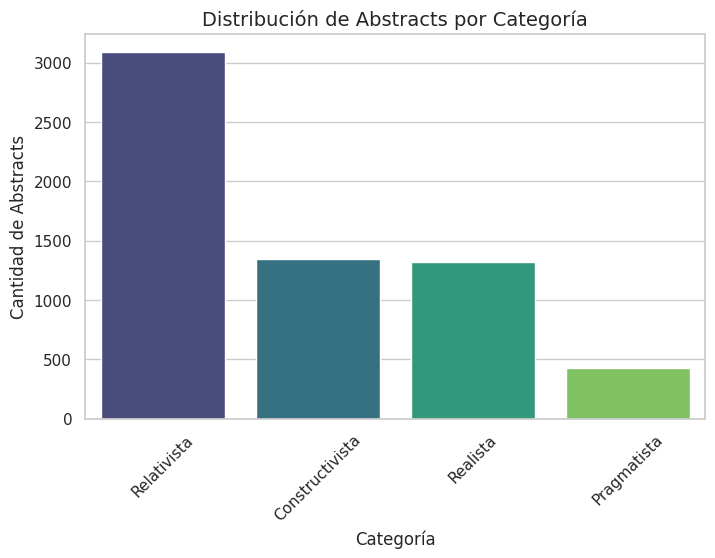

In [ ]:
# 📊 Gráfico 1: Distribución de Categorías
plt.figure(figsize=(8, 5))
sns.barplot(x=category_counts.index, y=category_counts.values, hue=category_counts.index, legend=False, palette="viridis")
plt.title("Distribución de Abstracts por Categoría", fontsize=14)
plt.xlabel("Categoría", fontsize=12)
plt.ylabel("Cantidad de Abstracts", fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px


# Filtrar desde el año 1950
df_filtered = df_classified[(df_classified["Year"] >= 1950) & (df_classified["Year"] <= 2025)]

# Agrupar por Año y Categoría
yearly_by_category = df_filtered.groupby(["Year", "Classification"]).size().reset_index(name='Cantidad')

# Crear gráfico interactivo
fig = px.line(
    yearly_by_category,
    x="Year",
    y="Cantidad",
    color="Classification",
    markers=True,
    title="Evolución de Publicaciones desde 1950 por Corriente Filosófica"
)

fig.update_layout(
    xaxis_title="Año",
    yaxis_title="Cantidad de Publicaciones",
    title_x=0.5,
    legend_title="Corriente",
    hovermode="x unified"
)

fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Se asume que df_classified es el DataFrame original con las columnas "Year" y "Classification"

# 1. Filtrar desde el año 1950 hasta 2025
df_filtered = df_classified[(df_classified["Year"] >= 1950) & (df_classified["Year"] <= 2025)]

# 2. Agrupar por Año y Categoría para obtener la cantidad de publicaciones por grupo
yearly_by_category = df_filtered.groupby(["Year", "Classification"]).size().reset_index(name='Cantidad')

# 3. Calcular el total de publicaciones por año
total_por_año = df_filtered.groupby("Year").size().reset_index(name="Total")

# 4. Unir ambos DataFrames para tener, en cada fila, el total por año junto con la cantidad por categoría
df_merged = pd.merge(yearly_by_category, total_por_año, on="Year")

# 5. Calcular la proporción (porcentaje) que representa cada categoría en ese año
df_merged["Proporcion"] = df_merged["Cantidad"] / df_merged["Total"] * 100

# 6. Crear gráfico interactivo con Plotly Express utilizando la proporción en lugar de la cantidad absoluta
fig = px.line(
    df_merged,
    x="Year",
    y="Proporcion",
    color="Classification",
    markers=True,
    title="Proporción de Publicaciones desde 1950 por Corriente Filosófica"
)

# Configuración del layout del gráfico
fig.update_layout(
    xaxis_title="Año",
    yaxis_title="Porcentaje de Publicaciones (%)",
    title_x=0.5,
    legend_title="Corriente",
    hovermode="x unified"
)

fig.show()


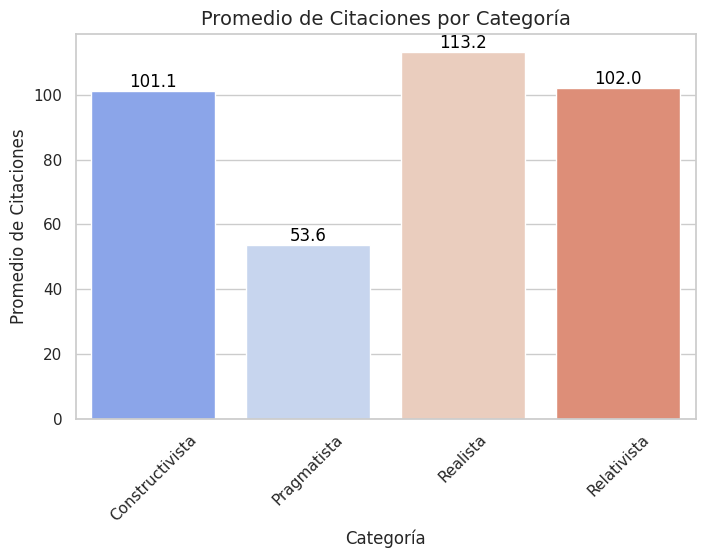

In [ ]:
# 📊 Gráfico 3: Promedio de Citaciones por Categoría

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=citations_per_category.reset_index(),
    x="Classification",
    y="Citations_counts",
    hue="Classification",
    dodge=False,
    legend=False,
    palette="coolwarm"
)


for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black')

plt.title("Promedio de Citaciones por Categoría", fontsize=14)
plt.xlabel("Categoría", fontsize=12)
plt.ylabel("Promedio de Citaciones", fontsize=12)
plt.xticks(rotation=45)
plt.show()


### Clustering

Se desarrolla este clustering conforme a las 4 macro categorías que tenemos (Constructivismo, Pragmatismo, Realismo y Relativismo) dentro de estos es impotante identificar los subtemas existentes dentro de cada corriente filosófica.

In [ ]:
# 1. Librerías necesarias
!pip install bertopic umap-learn hdbscan

import pandas as pd
from bertopic import BERTopic
import matplotlib.pyplot as plt

In [ ]:

# Definir variables necesarias
categories = df_classified["Classification"].unique()
clustered_dfs = {}

for category in categories:
    print(f"\n🔍 Procesando categoría: {category}")
    df_subset = df_classified[df_classified["Classification"] == category].copy()

    if df_subset.shape[0] < 5:
        print(f"⚠️ Muy pocos documentos en {category}, se omite.")
        continue

    abstracts = df_subset["Abstract"].dropna().tolist()

    topic_model = BERTopic(language="english", verbose=True)
    topics, _ = topic_model.fit_transform(abstracts)

    df_subset["Topic"] = topics

    # Validar temas válidos y visualizables
    topic_info = topic_model.get_topic_info()
    valid_topics = topic_info[~topic_info["Topic"].isin([-1]) & (topic_info["Count"] > 1)]

    if not valid_topics.empty and valid_topics.shape[0] >= 2:
        fig = topic_model.visualize_topics()
        fig.show()
    else:
        print(f"⚠️ No se pudieron formar suficientes temas válidos en '{category}' para visualizar.")

    clustered_dfs[category] = df_subset
    topic_model.save(f"bertopic_model_{category.lower()}.bin")


2025-04-09 02:13:02,700 - BERTopic - Embedding - Transforming documents to embeddings.



🔍 Procesando categoría: Relativista


Batches:   0%|          | 0/98 [00:00<?, ?it/s]

2025-04-09 02:13:14,593 - BERTopic - Embedding - Completed ✓
2025-04-09 02:13:14,594 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-04-09 02:13:30,548 - BERTopic - Dimensionality - Completed ✓
2025-04-09 02:13:30,550 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-04-09 02:13:30,680 - BERTopic - Cluster - Completed ✓
2025-04-09 02:13:30,684 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-04-09 02:13:31,069 - BERTopic - Representation - Completed ✓


2025-04-09 02:13:31,477 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
2025-04-09 02:13:31,934 - BERTopic - Embedding - Transforming documents to embeddings.


...

2025-04-09 02:13:44,119 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
2025-04-09 02:13:44,480 - BERTopic - Embedding - Transforming documents to embeddings.



🔍 Procesando categoría: Realista


Batches:   0%|          | 0/42 [00:00<?, ?it/s]

2025-04-09 02:13:47,980 - BERTopic - Embedding - Completed ✓
2025-04-09 02:13:47,982 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-04-09 02:13:52,223 - BERTopic - Dimensionality - Completed ✓
2025-04-09 02:13:52,227 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-04-09 02:13:52,308 - BERTopic - Cluster - Completed ✓
2025-04-09 02:13:52,316 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-04-09 02:13:52,598 - BERTopic - Representation - Completed ✓


ValueError: zero-size array to reduction operation maximum which has no identity

In [ ]:
# Unir todos los resultados con sus temas asignados
df_combined = pd.concat(clustered_dfs.values(), ignore_index=True)

# Guardar para revisión del cliente
df_combined.to_csv("/content/classified_abstracts_with_bertopic_topics.csv", index=False)

print("✅ Clasificación por temas completada. Archivo listo para revisión.")

### Análisis de Palabras Clave por Cluster


 Analizando subclusters dentro de Constructivista


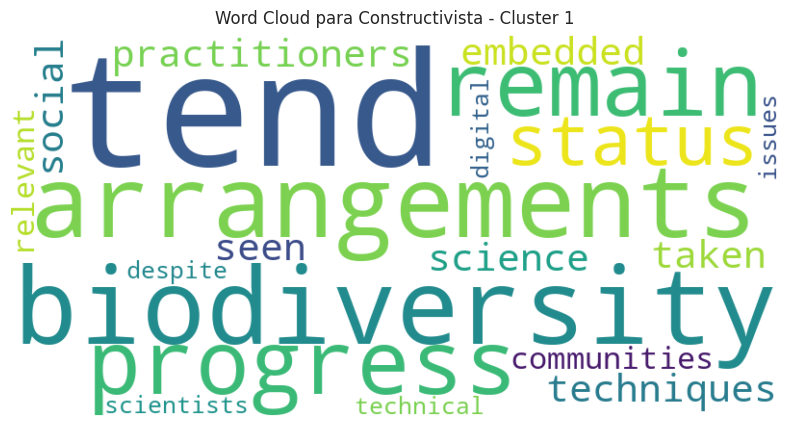

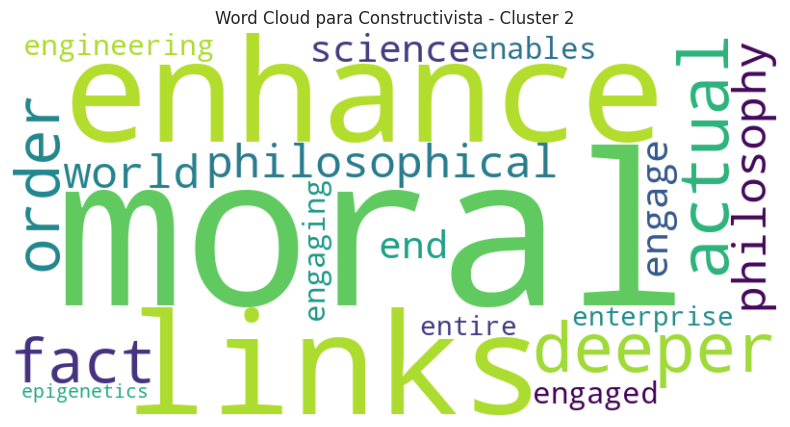

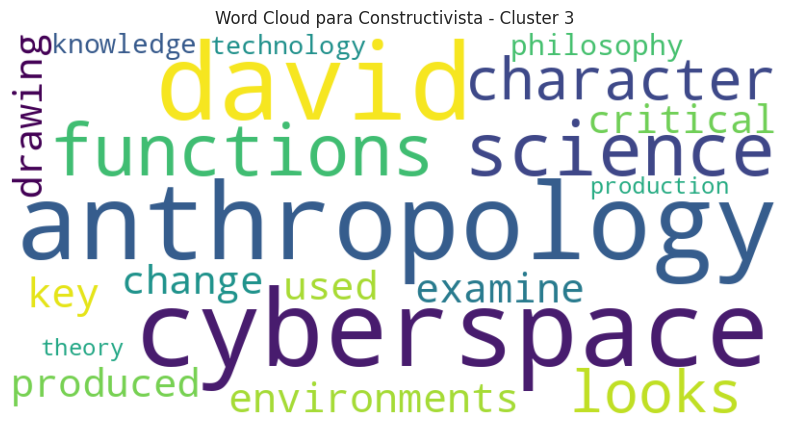

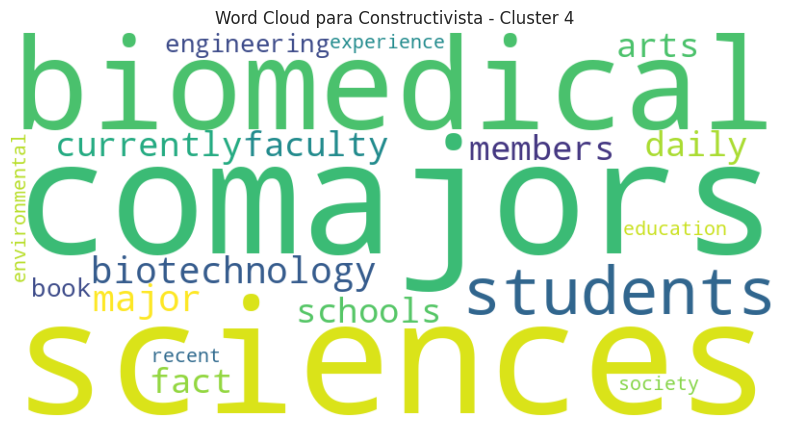

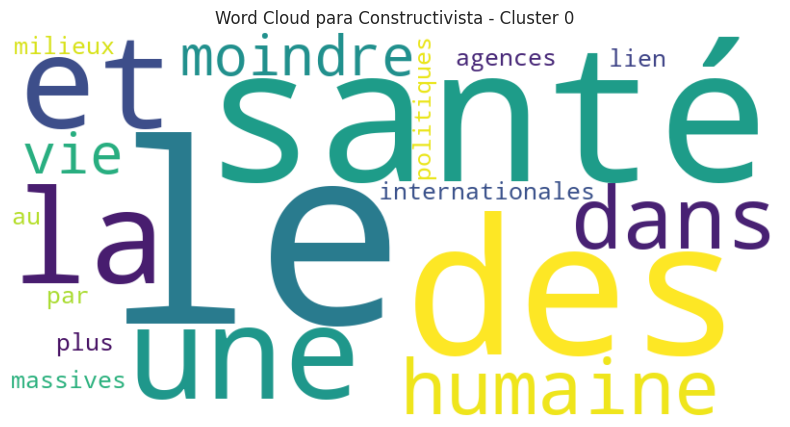


 Analizando subclusters dentro de Pragmatista


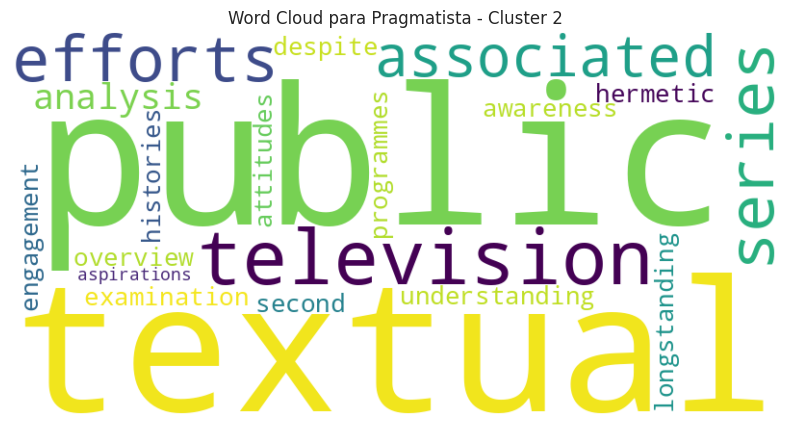

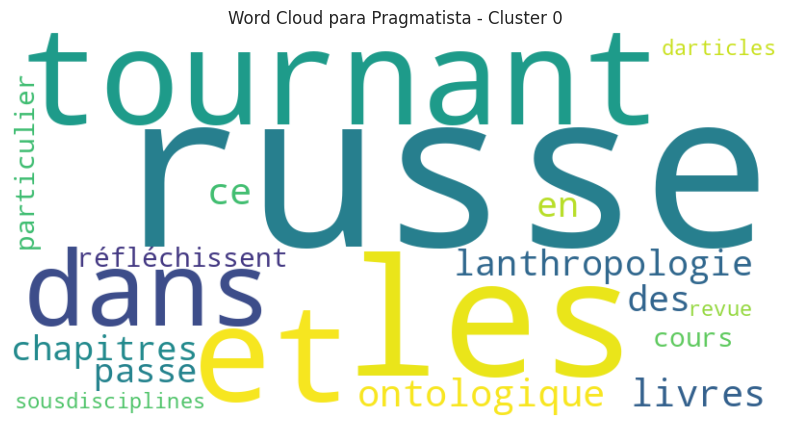

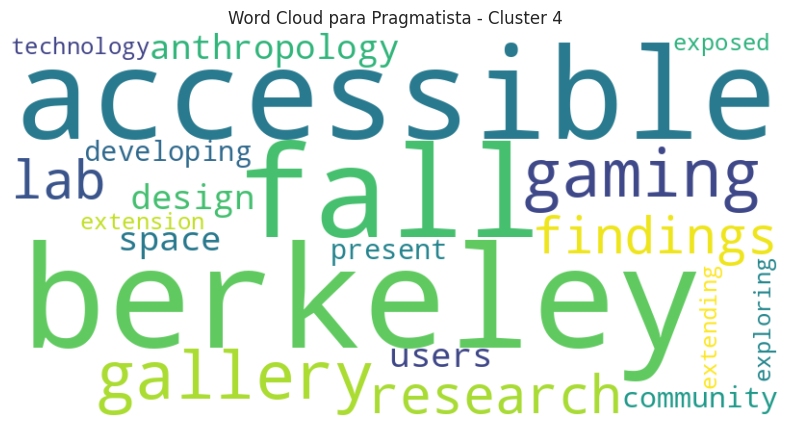

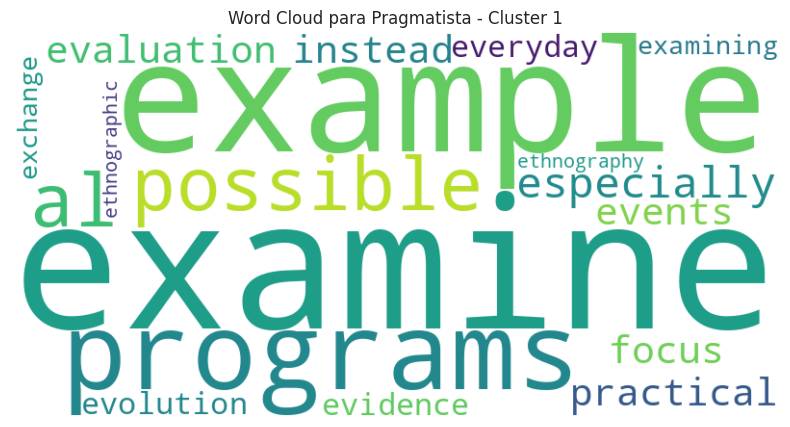

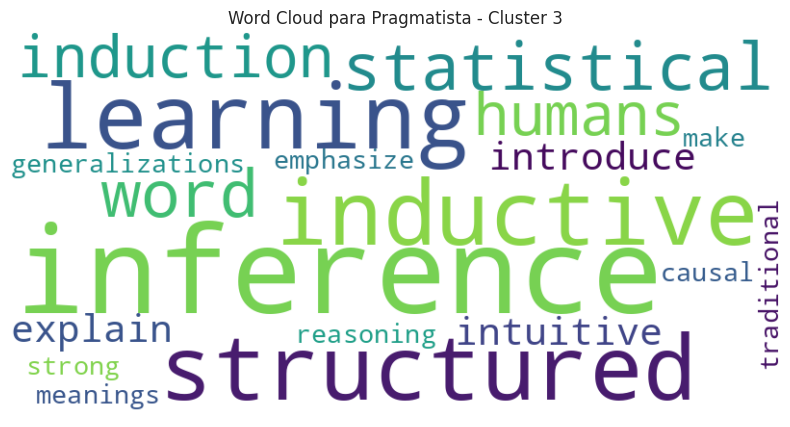


 Analizando subclusters dentro de Realista


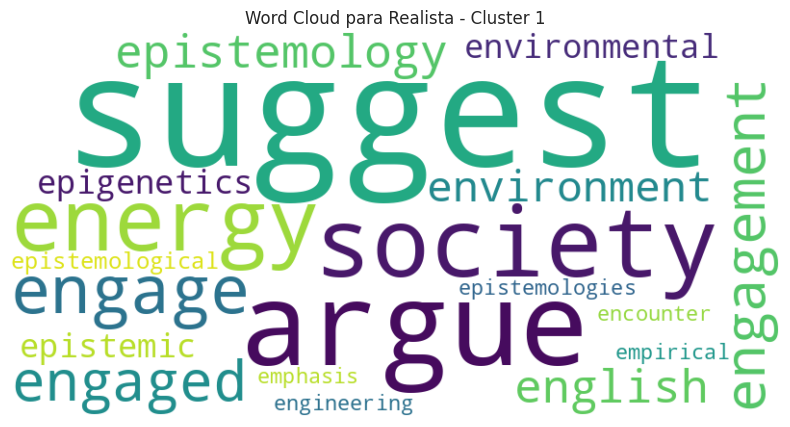

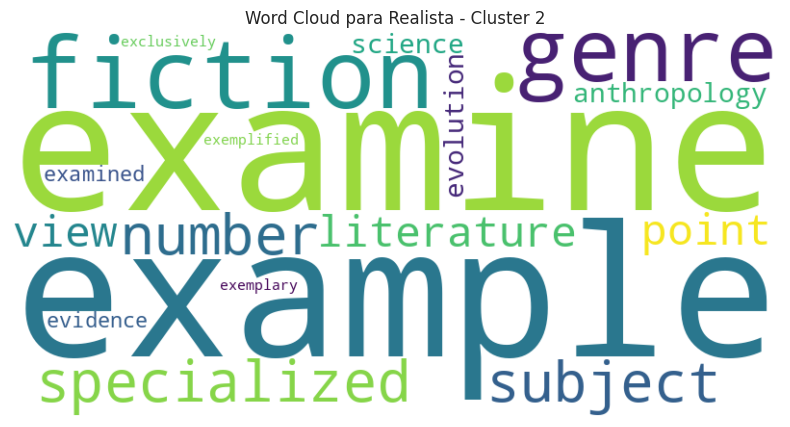

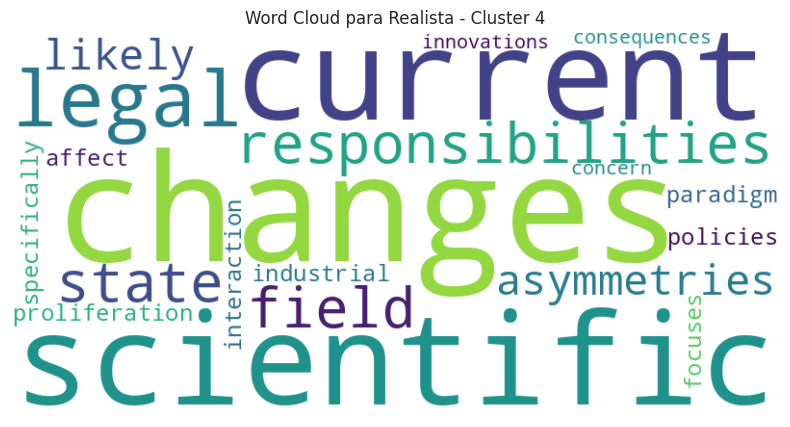

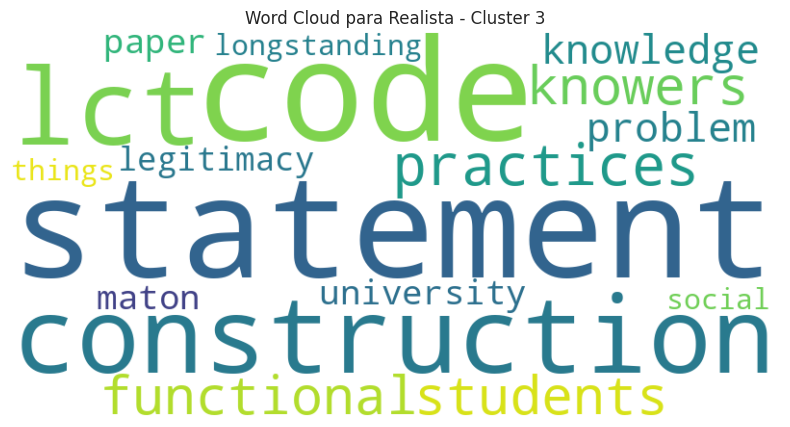

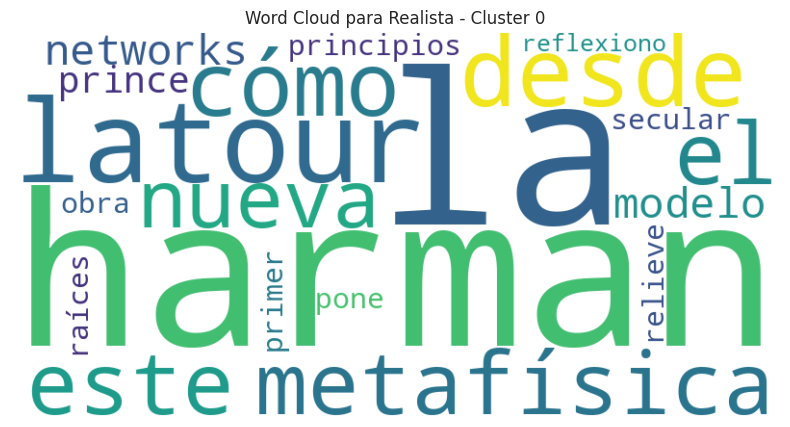


 Analizando subclusters dentro de Relativista


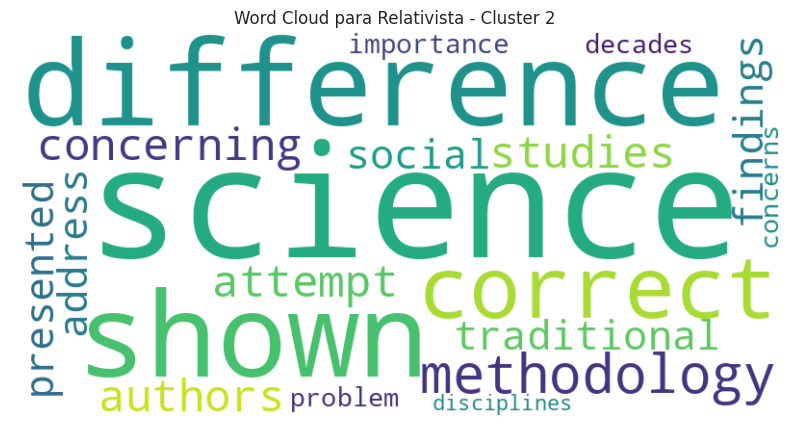

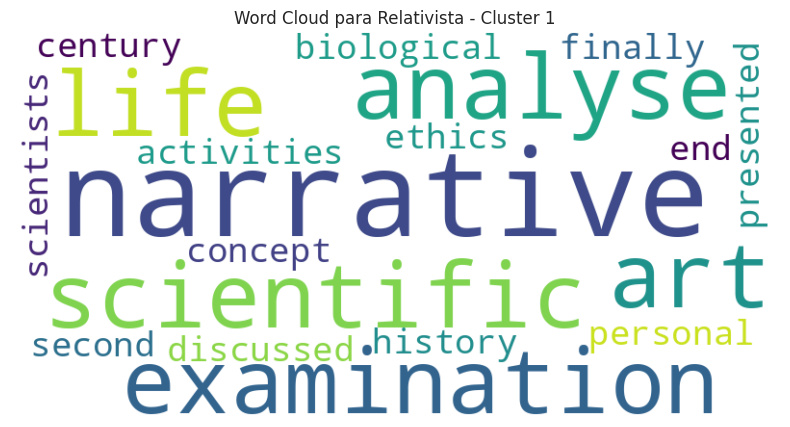

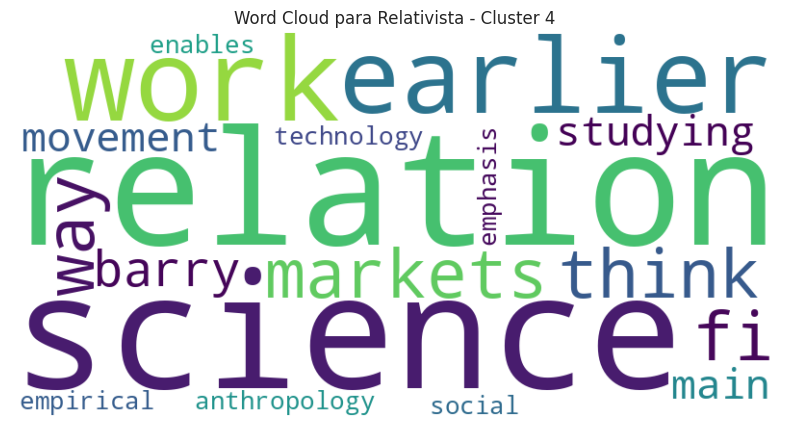

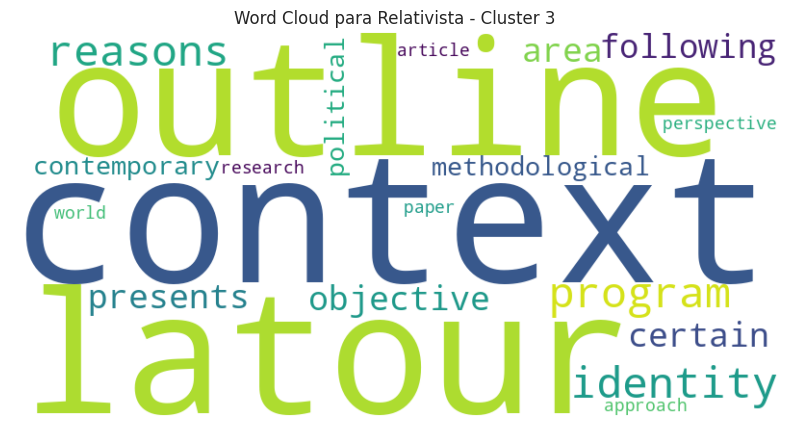

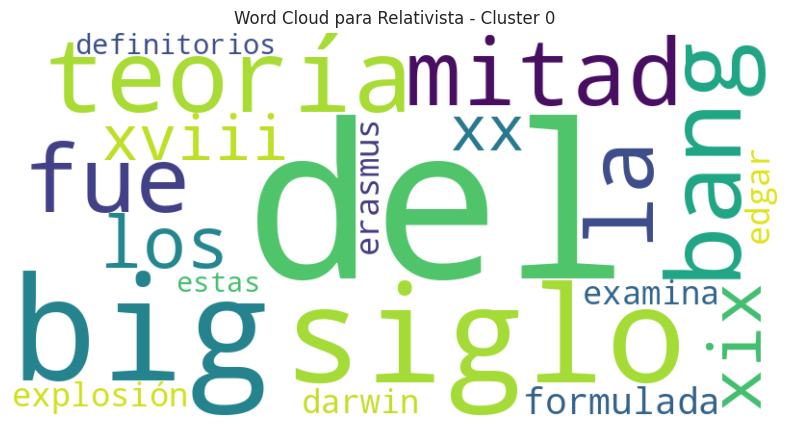

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud

#  Analizar palabras clave dentro de cada cluster
def get_top_keywords(texts, n_terms=10):
    vectorizer = TfidfVectorizer(max_features=1000, stop_words="english")
    X = vectorizer.fit_transform(texts)
    feature_array = np.array(vectorizer.get_feature_names_out())
    tfidf_sorting = np.argsort(X.toarray()).flatten()[::-1]

    top_n = feature_array[tfidf_sorting][:n_terms]
    return top_n

# Generar nubes de palabras para cada cluster en cada categoría
categories = ["Constructivista", "Pragmatista", "Realista", "Relativista"]
for category in categories:
    print(f"\n Analizando subclusters dentro de {category}")

    df_subset = df_classified[df_classified["Classification"] == category]

    for cluster in df_subset["Cluster"].unique():
        cluster_texts = df_subset[df_subset["Cluster"] == cluster]["cleaned_abstract"]
        keywords = get_top_keywords(cluster_texts, n_terms=20)

        #  Crear Word Cloud
        wordcloud = WordCloud(width=800, height=400, background_color="white").generate(" ".join(keywords))

        #  Visualizar Word Cloud
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"Word Cloud para {category} - Cluster {cluster}")
        plt.show()


#### Etiquetar Clusters de acuerdo a las bolsas de palabras

In [ ]:
import pandas as pd

# Cargar el dataset previamente generado con los clusters internos
input_path = "/content/drive/My Drive/classified_abstracts_with_internal_clusters.csv"
df_combined_clusters = pd.read_csv(input_path)

# Definir las etiquetas manualmente para cada cluster dentro de cada categoría
cluster_labels = {
    "Constructivista": {
        0: "Globalización y Políticas de Salud en la Ciencia Constructivista",
        1: "Construcción del Conocimiento en Ciencia y Medio Ambiente",
        2: "Construcción de la Moral y Ética en la Ciencia",
        3: "Construcción del Conocimiento Digital y Antropológico",
        4: "Educación y Construcción del Conocimiento en Biotecnología",
    },
    "Pragmatista": {
        0: "El Giro Ruso y su Impacto en la Filosofía Pragmatista",
        1: "Métodos de Evaluación y Evidencia en el Pragmatismo",
        2: "Medios de Comunicación y Difusión del Conocimiento Pragmatista",
        3: "Métodos de Inferencia y Aprendizaje en el Pragmatismo",
        4: "Accesibilidad y Tecnología en la Construcción del Conocimiento Pragmatista",
    },
    "Realista": {
        0: "Realismo Metafísico y Filosofía Contemporánea",
        1: "Epistemología Realista y Sociedad",
        2: "Realismo en Literatura y Ciencia Ficción",
        3: "Realismo y Construcción del Conocimiento Académico",
        4: "Realismo Científico y Políticas Públicas",
    },
    "Relativista": {
        0: "Historia del Conocimiento y el Relativismo Temporal",
        1: "Relativismo en la Narrativa Científica y Artística",
        2: "Diversidad Metodológica y Relativismo en los Estudios Sociales",
        3: "Relativismo Político y Construcción del Conocimiento",
        4: "Relativismo Económico y Ciencia Social",
    }
}

# Asignar las etiquetas basadas en la clasificación y el cluster
def assign_labels(row):
    category = row["Classification"]
    cluster = row["Cluster"]
    return cluster_labels.get(category, {}).get(cluster, "Sin etiqueta")

df_combined_clusters["Cluster_Label"] = df_combined_clusters.apply(assign_labels, axis=1)

# Guardar el dataset final con las etiquetas
output_path = "/content/drive/My Drive/classified_abstracts_with_labeled_clusters.csv"
df_combined_clusters.to_csv(output_path, index=False)

print(f"\n✅ Clusters etiquetados correctamente. Archivo guardado en: {output_path}")



✅ Clusters etiquetados correctamente. Archivo guardado en: /content/drive/My Drive/classified_abstracts_with_labeled_clusters.csv
